# 11.2 — CVA/DVA y wrong-way risk

**CVA** ajusta el valor de un derivado por el riesgo de default de la CONTRAPARTE,
integrando la exposición esperada positiva (11.1) contra la densidad de default de esa
contraparte. **DVA** es el simétrico (exposición negativa, curva de hazard propia).
**Wrong-way risk**: cuando la exposición y la probabilidad de default de la contraparte
están correlacionadas — el caso donde CVA "ingenuo" (calculado con exposición y default
independientes) subestima el riesgo real.

## 0. Configuración

Reusa (redefinido localmente) la simulación de exposición de un swap 5Y de 11.1.

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df, par_swap_rate
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

a, sigma = 0.05, 0.01
payment_times_A = np.arange(1.0, 6.0)
K_A = par_swap_rate(nelson_siegel_df, payment_times_A)

lam_C = 0.02  # hazard de la contraparte
R_C = 0.4  # recovery de la contraparte
n_paths = 200_000
check_times = np.concatenate([[0.25], np.arange(0.5, 5.0, 0.5), [4.95]])

In [2]:
def instantaneous_forward(t, eps=1e-6):
    t = max(t, 1e-6)
    return (np.log(nelson_siegel_df(t - eps)) - np.log(nelson_siegel_df(t + eps))) / (2.0 * eps)


def hull_white_bond(t, T, r_t, a, sigma):
    B = (1.0 - np.exp(-a * (T - t))) / a
    f0t = instantaneous_forward(t)
    return ((nelson_siegel_df(T) / nelson_siegel_df(t))
            * np.exp(B * f0t - sigma ** 2 / (4 * a) * B ** 2 * (1.0 - np.exp(-2 * a * t)))
            * np.exp(-B * r_t))


def swap_value_remaining(t, r_t, K, all_payment_times, a, sigma):
    remaining = all_payment_times[all_payment_times > t + 1e-9]
    if len(remaining) == 0:
        return np.zeros_like(r_t)
    tau = np.diff(np.concatenate([[t], remaining]))
    dfs = np.array([hull_white_bond(t, Ti, r_t, a, sigma) for Ti in remaining])
    return (1.0 - dfs[-1]) - K * np.sum(tau[:, None] * dfs, axis=0)


def ou_exact_joint(a, sigma, t, n_paths, rng):
    var_x = sigma ** 2 / (2 * a) * (1.0 - np.exp(-2 * a * t))
    var_I = sigma ** 2 / a ** 2 * (t - 2 / a * (1 - np.exp(-a * t)) + 1 / (2 * a) * (1 - np.exp(-2 * a * t)))
    cov_xI = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    cov = np.array([[var_x, cov_xI], [cov_xI, var_I]])
    L = np.linalg.cholesky(cov)
    Z = rng.standard_normal((n_paths, 2))
    s = Z @ L.T
    return s[:, 0], var_x


def simulate_short_rate_and_factor(t, a, sigma, n_paths, rng):
    '''Devuelve r_t y el factor gaussiano estandarizado Z_rate=x_t/std(x_t) (para correlacionar con default).'''
    x_t, var_x = ou_exact_joint(a, sigma, t, n_paths, rng)
    alpha_t = sigma ** 2 / (2 * a ** 2) * (1.0 - np.exp(-a * t)) ** 2
    r_t = instantaneous_forward(t) + alpha_t + x_t
    Z_rate = x_t / np.sqrt(var_x)
    return r_t, Z_rate

## 1. CVA sin correlación (exposición y default independientes)

$$\text{CVA} = (1-R_C)\sum_i P(0,T_i)\,EE(T_i)\,\Delta P_{\text{default}}(T_i)$$
con $\Delta P_{\text{default}}(T_i)=S(T_{i-1})-S(T_i)$ la probabilidad de default en el
intervalo (curva de supervivencia con hazard constante $\lambda_C$, igual que 10.1/10.2),
sumado sobre la malla de fechas de observación de la exposición.

In [3]:
def cva_independent(check_times, lam_C, R_C, n_paths, rng):
    EE = []
    for t in check_times:
        r_t, _ = simulate_short_rate_and_factor(t, a, sigma, n_paths, rng)
        V = swap_value_remaining(t, r_t, K_A, payment_times_A, a, sigma)
        EE.append(np.maximum(V, 0.0).mean())
    EE = np.array(EE)
    surv = np.exp(-lam_C * check_times)
    surv_prev = np.concatenate([[1.0], surv[:-1]])
    dP_default = surv_prev - surv
    discs = nelson_siegel_df(check_times)
    cva = (1.0 - R_C) * np.sum(EE * discs * dP_default)
    return cva, EE


cva0, EE0 = cva_independent(check_times, lam_C, R_C, n_paths, rng)
print(f"CVA (independiente): {cva0:.6f}")

# DVA simetrico: exposicion NEGATIVA, propia curva de hazard (aqui, por simplicidad, la misma lambda)
def dva_independent(check_times, lam_own, R_own, n_paths, rng):
    EE_neg = []
    for t in check_times:
        r_t, _ = simulate_short_rate_and_factor(t, a, sigma, n_paths, rng)
        V = swap_value_remaining(t, r_t, K_A, payment_times_A, a, sigma)
        EE_neg.append(np.maximum(-V, 0.0).mean())
    EE_neg = np.array(EE_neg)
    surv = np.exp(-lam_own * check_times)
    surv_prev = np.concatenate([[1.0], surv[:-1]])
    dP_default = surv_prev - surv
    discs = nelson_siegel_df(check_times)
    return (1.0 - R_own) * np.sum(EE_neg * discs * dP_default)


lam_own = 0.015
dva0 = dva_independent(check_times, lam_own, R_C, n_paths, rng)
print(f"DVA (independiente, propia hazard={lam_own}): {dva0:.6f}")
print(f"CVA-DVA: {cva0 - dva0:.6f} (signo depende de quien esta mas 'in the money' en expectativa)")

CVA (independiente): 0.000622
DVA (independiente, propia hazard=0.015): 0.000314
CVA-DVA: 0.000308 (signo depende de quien esta mas 'in the money' en expectativa)


## 2. Wrong-way risk

Correlacionar el factor de tasas $Z_{\text{rate}}$ (estandarizado, del proceso $x_t$ de
Hull-White) con un factor de default $Z_{\text{default}}=\rho\,Z_{\text{rate}}+\sqrt{1-\rho^2}\,\varepsilon$
(cópula gaussiana simplificada, mismo mecanismo de 10.3, aquí de un solo factor de
mercado en vez de entre nombres). En vez de simular tiempos de default explícitos (que
requeriría una malla mucho más fina para capturar bien la cola), se usa una
**aproximación de inclinación lineal** (documentada como tal, no una construcción de
cópula completa): el peso de exposición en cada fecha se ajusta linealmente por la
correlación, $E[EE(t)\,(1+\rho\,Z_{\text{rate}})]$ — de primer orden en $\rho$, suficiente
para capturar el SIGNO del efecto de wrong/right-way risk, no su magnitud exacta.

CVA (rho=0, control -- debe coincidir con la Seccion 1): 0.000621 vs 0.000622
CVA (rho=+0.6, wrong-way risk): 0.001049
CVA (rho=-0.6, right-way risk): 0.000194


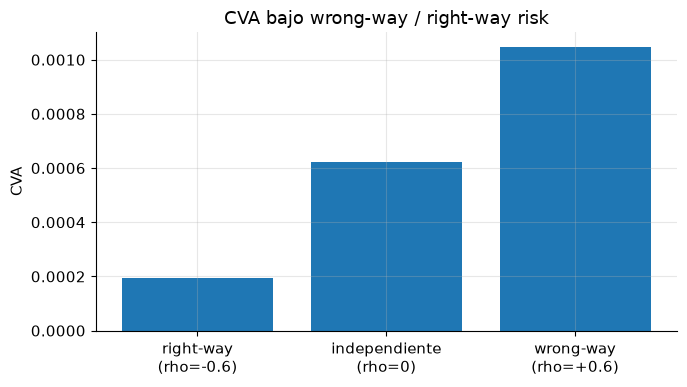

In [4]:
def cva_with_wwr(rho_wwr, check_times, lam_C, R_C, n_paths, rng):
    cva_sum = 0.0
    surv_prev = 1.0
    for t in check_times:
        r_t, Z_rate = simulate_short_rate_and_factor(t, a, sigma, n_paths, rng)
        V = swap_value_remaining(t, r_t, K_A, payment_times_A, a, sigma)
        EE_t = np.maximum(V, 0.0)
        weight = np.mean(EE_t * (1.0 + rho_wwr * Z_rate))
        surv_t = np.exp(-lam_C * t)
        dP_default_t = surv_prev - surv_t
        cva_sum += (1.0 - R_C) * nelson_siegel_df(t) * max(weight, 0.0) * dP_default_t
        surv_prev = surv_t
    return cva_sum


cva_zero = cva_with_wwr(0.0, check_times, lam_C, R_C, n_paths, rng)
cva_wwr = cva_with_wwr(0.6, check_times, lam_C, R_C, n_paths, rng)
cva_rwr = cva_with_wwr(-0.6, check_times, lam_C, R_C, n_paths, rng)

print(f"CVA (rho=0, control -- debe coincidir con la Seccion 1): {cva_zero:.6f} vs {cva0:.6f}")
print(f"CVA (rho=+0.6, wrong-way risk): {cva_wwr:.6f}")
print(f"CVA (rho=-0.6, right-way risk): {cva_rwr:.6f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["right-way\n(rho=-0.6)", "independiente\n(rho=0)", "wrong-way\n(rho=+0.6)"],
       [cva_rwr, cva_zero, cva_wwr])
ax.set_ylabel("CVA")
ax.set_title("CVA bajo wrong-way / right-way risk")
fig.tight_layout(); plt.show()

## 3. Validación

Tres chequeos, todos sobre las cantidades ya calculadas: (1) el CVA calculado con la aproximación de la Sección 2 en $\rho=0$ coincide con el CVA independiente de la Sección 1 (son el mismo cálculo por dos caminos distintos, así que deben coincidir dentro de un margen razonable); (2) y (3) son direccionales — wrong-way risk debe subir el CVA y right-way risk debe bajarlo, respecto al caso independiente, sin importar la magnitud exacta (la aproximación de inclinación lineal de la Sección 2 solo garantiza el signo, no el valor preciso).

In [5]:
rel_diff_control = abs(cva_zero - cva0) / cva0
check1 = rel_diff_control < 0.05
print(f"1. CVA con rho=0 coincide con el CVA independiente (mismo calculo, dos caminos): "
      f"diff relativa={rel_diff_control:.2%} (<5%? {check1})")

check2 = cva_wwr > cva_zero
print(f"2. wrong-way risk (rho>0) aumenta el CVA respecto al independiente: {check2}")

check3 = cva_rwr < cva_zero
print(f"3. right-way risk (rho<0) reduce el CVA respecto al independiente: {check3}")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 (chequeos direccionales, no de magnitud exacta -- ver Seccion 2).")

1. CVA con rho=0 coincide con el CVA independiente (mismo calculo, dos caminos): diff relativa=0.07% (<5%? True)
2. wrong-way risk (rho>0) aumenta el CVA respecto al independiente: True
3. right-way risk (rho<0) reduce el CVA respecto al independiente: True

Validacion completa: 3/3 (chequeos direccionales, no de magnitud exacta -- ver Seccion 2).


## Referencias

- Gregory, J. (2015). *The xVA Challenge*, cap. 5-8 (CVA/DVA), cap. 17 (wrong-way risk).
- Brigo, D., Pallavicini, A., Papatheodorou, V. (2011). *Arbitrage-Free Valuation of
  Bilateral Counterparty Risk for Interest-Rate Products: Impact of Volatilities and
  Correlations*.